# LeNet-5 in PyTorch, and convolution from scratch

LeNet-5 (LeCun et al., 1998) on MNIST, padded from 28×28 to the 32×32 it was designed for.

```
(1,32,32) --C1--> (6,28,28) --S2--> (6,14,14) --C3--> (16,10,10)
          --S4--> (16,5,5)  --C5--> (120,1,1) --F6--> (84) --> (10)
```

1. **The formulas** — convolution forward, output shape, parameter count, the three gradients.
2. **LeNet-5 in PyTorch** — trained on MNIST, with the curves worth looking at.
3. **From scratch, in NumPy** — the pieces that actually get asked about: naive convolution, the
   `im2col` rewrite, the backward pass, pooling, and BatchNorm. Verified against autograd, with a
   gradient sanity check rather than a full training run.

device cuda   train (60000, 1, 32, 32)   test (10000, 1, 32, 32)


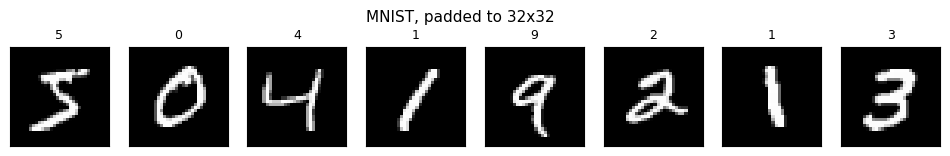

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'


def load_mnist(root='../data', pad=2):
    """MNIST as (N, 1, 32, 32) floats in [0, 1]. Downloads once, then caches a .npz.

    pad=2 turns 28x28 into 32x32. LeNet's C1 is an unpadded 5x5 conv, so without
    this the border pixels of a digit could never sit at the centre of a filter
    window -- and every layer size downstream assumes 32x32.
    """
    import gzip, os, struct, urllib.request
    files = {'Xtr': 'train-images-idx3-ubyte.gz', 'ytr': 'train-labels-idx1-ubyte.gz',
             'Xte': 't10k-images-idx3-ubyte.gz',  'yte': 't10k-labels-idx1-ubyte.gz'}
    cache = os.path.join(root, 'mnist_np.npz')

    if os.path.exists(cache):
        raw = dict(np.load(cache))
    else:
        raw_dir = os.path.join(root, 'MNIST', 'raw')
        os.makedirs(raw_dir, exist_ok=True)
        raw = {}
        for key, name in files.items():
            path = os.path.join(raw_dir, name)
            if not os.path.exists(path):
                print('downloading', name)
                urllib.request.urlretrieve('https://ossci-datasets.s3.amazonaws.com/mnist/' + name, path)
            # IDX format: magic number (low byte = rank), one big-endian int32 per
            # dimension, then the raw bytes.
            with gzip.open(path, 'rb') as f:
                magic, = struct.unpack('>I', f.read(4))
                dims = struct.unpack('>' + 'I' * (magic & 0xFF), f.read(4 * (magic & 0xFF)))
                raw[key] = np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)
        np.savez_compressed(cache, **raw)

    prep = lambda a: (np.pad(a, ((0, 0), (pad, pad), (pad, pad))) / 255.0)[:, None, :, :]
    return prep(raw['Xtr']), raw['ytr'].astype(np.int64), prep(raw['Xte']), raw['yte'].astype(np.int64)


Xtr, ytr, Xte, yte = load_mnist()
Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
Xte_t = torch.tensor(Xte, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
yte_t = torch.tensor(yte, dtype=torch.long)
print(f'device {device}   train {Xtr.shape}   test {Xte.shape}')

fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for ax, k in zip(axes, range(8)):
    ax.imshow(Xtr[k, 0], cmap='gray')
    ax.set_title(ytr[k], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('MNIST, padded to 32x32', fontsize=11)
plt.show()

## The formulas

**The symbols**, used the same way throughout and matching the names PyTorch uses:

| | |
| --- | --- |
| $N$ | batch size — how many images go through together |
| $C_{in}$, $C_{out}$ | input and output channels. $C_{in}$ is 1 for grayscale, 3 for RGB; $C_{out}$ is the number of filters, since one filter makes one output channel |
| $H$, $W$ | height and width of the input feature map |
| $H_{out}$, $W_{out}$ | height and width of the output feature map |
| $K_H$, $K_W$ | kernel height and width — the size of the sliding window, 5×5 in LeNet |
| $S$ | stride — how far the window moves between positions |
| $P$ | padding — rows/columns of zeros added to each side of the input |
| $X_{n,c,h,w}$ | input pixel: image $n$, channel $c$, row $h$, column $w$ |
| $W_{c_o,c,u,v}$ | weight: filter $c_o$, the slice of it that reads input channel $c$, at offset $(u,v)$ inside the window |
| $b_{c_o}$ | bias — one scalar per output channel, shared across every position |
| $Y_{n,c_o,i,j}$ | output value at position $(i,j)$ of output channel $c_o$, for image $n$ |
| $J$ | the scalar loss. $\partial J/\partial Y$ is the gradient handed down by the layer above; the backward pass turns it into $\partial J/\partial W$, $\partial J/\partial b$, $\partial J/\partial X$ |

The index letters stay fixed too: $n$ over the batch, $c$ over input channels, $c_o$ over filters,
$(i,j)$ over output positions, $(u,v)$ over positions inside the kernel.

**Convolution forward.** Each output is a dot product between one filter and one patch:

$$Y_{n,c_{o},i,j} = b_{c_{o}} + \sum_{c=1}^{C_{in}} \sum_{u=1}^{K_H} \sum_{v=1}^{K_W}
X_{n,\,c,\;iS+u-P,\;jS+v-P}\; W_{c_{o},\,c,\,u,\,v}$$

Line the filter up over a patch, multiply elementwise, sum, add the bias, slide by the stride $S$.
A filter reads **all** input channels at once, so one filter produces one output channel.
The index $iS+u-P$ is just "which input row does kernel offset $u$ land on when the window sits at
output row $i$": $iS$ walks the window along, $u$ steps inside it, $-P$ undoes the padding shift.
The three sums say the same thing three times over — every channel, every kernel row, every kernel
column contributes to the one output number.

**Output size** — just counting how many times the window fits:

$$H_{out} = \left\lfloor \frac{H + 2P - K_H}{S} \right\rfloor + 1$$

$H + 2P$ is the padded height, subtracting $K_H$ leaves the distance the window can travel, dividing
by $S$ counts the steps it takes, and the $+1$ is the starting position. The floor is the window
running out of room at the edge; those leftover pixels are dropped. $W_{out}$ is the same with
$W$, $K_W$.

**Parameter count** — note that $H$ and $W$ do not appear. A conv layer's size is independent of the
image size; a dense layer's is not:

$$\#\text{params} = C_{out}\,C_{in}K_HK_W + C_{out}$$

$C_{in}K_HK_W$ is the weights in one filter (a $K_H \times K_W$ window over every input channel),
times $C_{out}$ filters, plus $C_{out}$ biases.

**`im2col`.** Copy every patch the filter visits into a column, and the whole layer is one matmul:

$$\mathbf{Y} = \underbrace{\mathbf{W}_{\text{flat}}}_{C_{out} \times C_{in}K_HK_W}
\cdot \underbrace{\text{im2col}(\mathbf{X})}_{C_{in}K_HK_W \times H_{out}W_{out}} + \mathbf{b}$$

$\mathbf{W}_{\text{flat}}$ is the weight tensor reshaped so each row is one filter flattened;
$\text{im2col}(\mathbf{X})$ has one column per output position, holding that window's pixels
flattened in the same order. The shared inner dimension $C_{in}K_HK_W$ is the length of one patch,
so the matmul computes every filter against every patch at once, and $\mathbf{b}$ is broadcast
across the columns.

**Backward.** The bias was added once per output position; each weight was used at *every* position;
each input pixel was read by every window covering it:

$$\frac{\partial J}{\partial b_{c_o}} = \sum_{n,i,j} \frac{\partial J}{\partial Y_{n,c_o,i,j}}
\qquad
\frac{\partial J}{\partial W_{c_o,c,u,v}} = \sum_{n,i,j}
\frac{\partial J}{\partial Y_{n,c_o,i,j}}\, X_{n,c,\,iS+u-P,\,jS+v-P}$$

$\partial J/\partial Y_{n,c_o,i,j}$ (`dout` in the code) is the incoming gradient, one number per
output element. The sums over $n,i,j$ are there because $b$ and $W$ are *shared* — reused at every
image and every position — so their gradients accumulate over all of them. In $\partial J/\partial W$
each output's gradient is multiplied by the input pixel that weight happened to multiply on the way
forward, the same index $iS+u-P$ as above.

$$\frac{\partial J}{\partial X_{n,c,h,w}} = \sum_{c_o,u,v}
\frac{\partial J}{\partial Y_{n,c_o,(h+P-u)/S,\,(w+P-v)/S}}\, W_{c_o,c,u,v}$$

Here $(h,w)$ is an input pixel and $(h+P-u)/S$ inverts the forward index: given the pixel and the
kernel offset $u$, it is the output position whose window covered that pixel. Terms where the
division is not exact don't exist — that window never landed there — and the sum runs over every
filter $c_o$ and every offset $(u,v)$ that did cover the pixel.

That last one is a full convolution with the kernel flipped in both directions — forward, a pixel
*scatters* into several outputs; backward, it *gathers* from those same outputs.

**Max pooling** takes the largest value in each window and has no parameters. Backward, the max is a
router: the winner receives the whole gradient, everything else zero.

$$Y_{n,c,i,j} = \max_{0 \le u,v < p} X_{n,c,\,iS+u,\,jS+v}$$

$p$ is the pooling window size (2 in LeNet, with $S = 2$ so the windows don't overlap), and $(u,v)$
ranges over that window. There is no sum over channels: pooling works on each channel separately,
so $C_{out} = C_{in}$, and no $P$ term because pooling is normally unpadded.

## LeNet-5

The modern form: ReLU instead of the paper's scaled `tanh`, max pooling instead of its trainable
subsampling, and a linear + softmax head instead of its Euclidean RBF output.

| layer | type | output | params |
| --- | --- | --- | --- |
| C1 | conv 6 × 5×5 | 6 × 28×28 | 156 |
| S2 | maxpool 2×2 | 6 × 14×14 | 0 |
| C3 | conv 16 × 5×5 | 16 × 10×10 | 2,416 |
| S4 | maxpool 2×2 | 16 × 5×5 | 0 |
| C5 | conv 120 × 5×5 | 120 × 1×1 | 48,120 |
| F6 | linear | 84 | 10,164 |
| out | linear | 10 | 850 |
| | | | **61,706** |

C5 stays a *convolution* rather than a `Linear`, which is what the paper calls it: 120 filters of
5×5 that happen to give 1×1 on a 32×32 input, but would give a feature map on anything larger.
78% of the parameters sit there, after the spatial structure has already been collapsed.

In [2]:
class LeNet5(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        # Conv2d(in_channels, out_channels, kernel_size) -- hyperparameters, not a shape.
        # Conv2d(1, 6, 5) = 6 filters of 5x5 reading 1 input channel, so the weight is
        # (6, 1, 5, 5) = (C_out, C_in, KH, KW) and params = 6*1*5*5 + 6 = 156. No batch
        # size appears: a conv layer's parameters depend on channels and kernel only,
        # never on N, H or W -- which is why the same layer takes any batch and any
        # image size. The "2d" means two SPATIAL dims (H, W), not a 2d tensor.
        # in_channels must match the previous layer's out_channels; MaxPool2d(2) halves
        # H and W but never touches the channel count.
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5), nn.ReLU(), nn.MaxPool2d(2),      # C1, S2: 32 -> 28 -> 14
            nn.Conv2d(6, 16, 5), nn.ReLU(), nn.MaxPool2d(2),     # C3, S4: 14 -> 10 -> 5
            nn.Conv2d(16, 120, 5), nn.ReLU(), nn.Flatten(),      # C5:      5 -> 1
            nn.Linear(120, 84), nn.ReLU(),                       # F6
            nn.Linear(84, n_classes))                            # output logits

    def forward(self, x):
        # x is 4d: (N, C_in, H, W) = (batch, channels, height, width), e.g. (128,1,32,32).
        # Conv/ReLU/MaxPool each map (N, C, H, W) -> (N, C', H', W'), carrying N through
        # untouched -- every image is processed independently with the same weights, so
        # a batch is just "do it N times" (BatchNorm would be the exception: it reduces
        # over N). Flatten defaults to start_dim=1, collapsing (N, 120, 1, 1) -> (N, 120)
        # and leaving the batch axis alone; Linear then maps the LAST axis, 120 -> 84.
        return self.net(x)                                       # (N, n_classes) logits


model = LeNet5()
print(f'{"layer":<12}{"output":>16}{"params":>10}')
x = torch.zeros(1, 1, 32, 32)          # (N=1, C_in=1, H=32, W=32): a batch of one image
for layer in model.net:
    x = layer(x)
    n = sum(p.numel() for p in layer.parameters())
    if n or isinstance(layer, (nn.MaxPool2d, nn.Flatten)):
        # shape[1:] drops N, so the table reads per-image and lines up with the one
        # above; the real tensor here is (1, 6, 28, 28) after C1, not (6, 28, 28).
        print(f'{type(layer).__name__:<12}{str(tuple(x.shape[1:])):>16}{n:>10,}')
print(f'{"total":<12}{"":>16}{sum(p.numel() for p in model.parameters()):>10,}')

layer                 output    params
Conv2d           (6, 28, 28)       156
MaxPool2d        (6, 14, 14)         0
Conv2d          (16, 10, 10)     2,416
MaxPool2d         (16, 5, 5)         0
Conv2d           (120, 1, 1)    48,120
Flatten               (120,)         0
Linear                 (84,)    10,164
Linear                 (10,)       850
total                           61,706


epoch 0  loss 0.3953  train 0.9630  test 0.9656
epoch 1  loss 0.1015  train 0.9783  test 0.9779

13s   test accuracy 0.9779   error 2.21%
LeCun et al. report 0.95% error for LeNet-5 without input distortions.


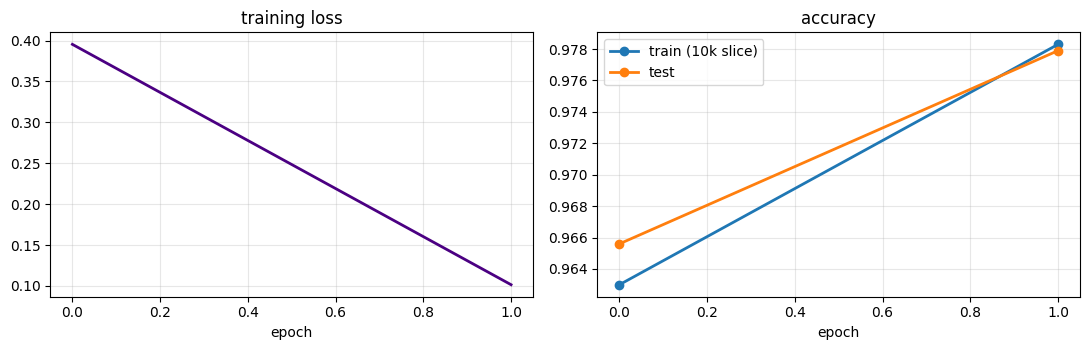

In [3]:
EPOCHS, BATCH = 2, 128

model = LeNet5().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()      # = log_softmax + NLL, so the model returns raw logits
Xte_d, yte_d = Xte_t.to(device), yte_t.to(device)

hist = {'loss': [], 'train_acc': [], 'test_acc': []}
t0 = time.perf_counter()
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(Xtr_t))
    running = 0.0
    for s in range(0, len(perm), BATCH):
        i = perm[s:s + BATCH]
        opt.zero_grad()
        loss = loss_fn(model(Xtr_t[i].to(device)), ytr_t[i].to(device))
        loss.backward()
        opt.step()
        running += loss.item() * len(i)

    model.eval()
    with torch.no_grad():
        # train accuracy on a fixed 10k slice, so the gap to test accuracy is readable
        tr_acc = (model(Xtr_t[:10000].to(device)).argmax(1) == ytr_t[:10000].to(device)).float().mean().item()
        logits = model(Xte_d)
        te_acc = (logits.argmax(1) == yte_d).float().mean().item()
    hist['loss'].append(running / len(perm))
    hist['train_acc'].append(tr_acc)
    hist['test_acc'].append(te_acc)
    print(f'epoch {epoch}  loss {hist["loss"][-1]:.4f}  train {tr_acc:.4f}  test {te_acc:.4f}')

proba = F.softmax(logits, dim=1).cpu().numpy()
acc = hist['test_acc'][-1]
print(f'\n{time.perf_counter() - t0:.0f}s   test accuracy {acc:.4f}   error {100 * (1 - acc):.2f}%')
print('LeCun et al. report 0.95% error for LeNet-5 without input distortions.')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(hist['loss'], lw=2, color='indigo')
axes[0].set_title('training loss'); axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3)
axes[1].plot(hist['train_acc'], lw=2, marker='o', label='train (10k slice)')
axes[1].plot(hist['test_acc'], lw=2, marker='o', label='test')
axes[1].set_title('accuracy'); axes[1].set_xlabel('epoch')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0     0.9653    0.9949    0.9799       980
           1     0.9894    0.9912    0.9903      1135
           2     0.9823    0.9690    0.9756      1032
           3     0.9348    0.9931    0.9630      1010
           4     0.9877    0.9847    0.9862       982
           5     0.9819    0.9731    0.9775       892
           6     0.9925    0.9729    0.9826       958
           7     0.9731    0.9844    0.9787      1028
           8     0.9852    0.9548    0.9698       974
           9     0.9908    0.9584    0.9743      1009

    accuracy                         0.9779     10000
   macro avg     0.9783    0.9776    0.9778     10000
weighted avg     0.9783    0.9779    0.9779     10000



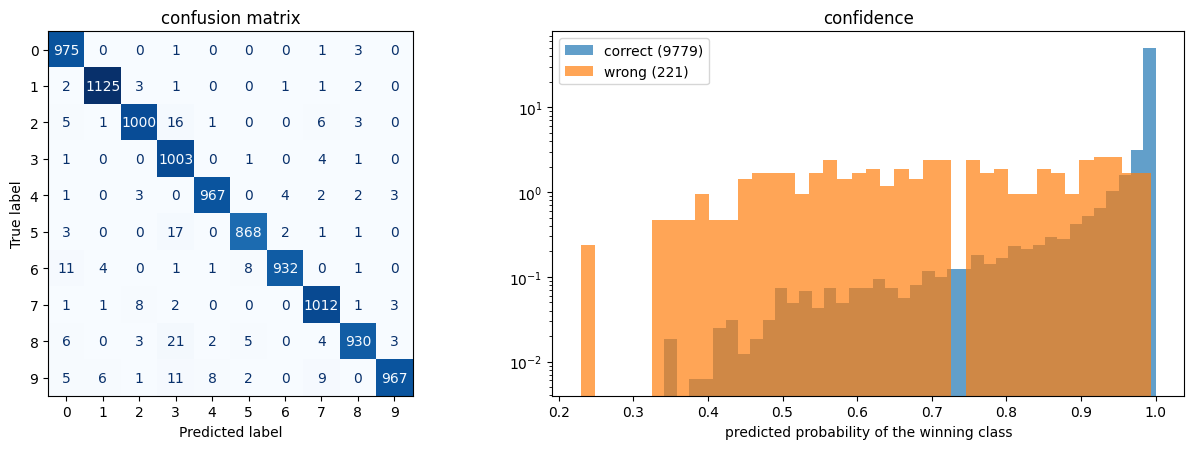

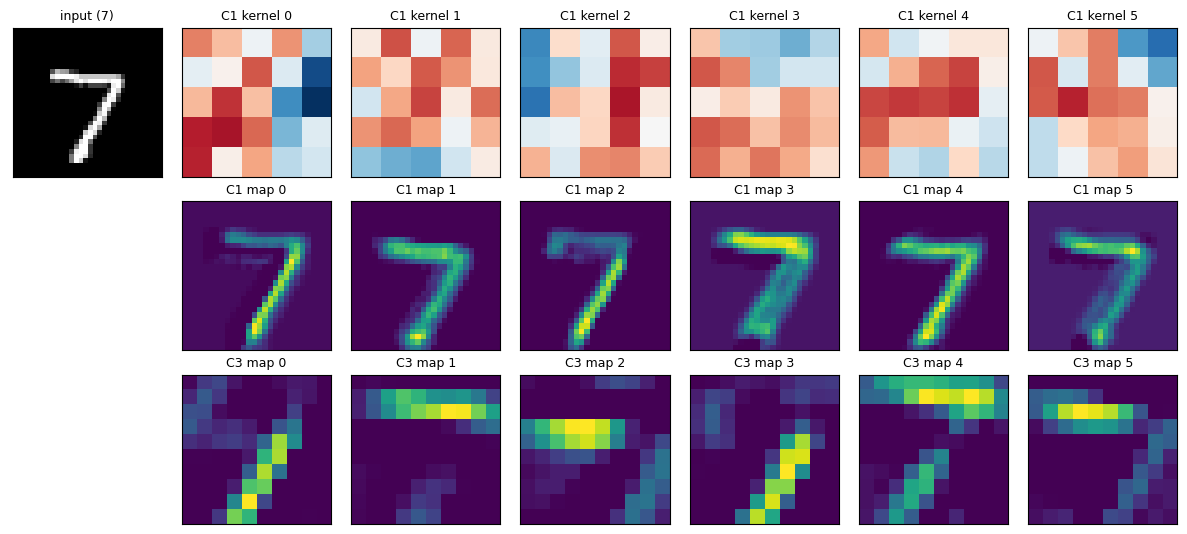

C1: one unit sees 5x5 pixels of the input
S2: one unit sees 6x6 pixels of the input
C3: one unit sees 14x14 pixels of the input
S4: one unit sees 16x16 pixels of the input
C5: one unit sees 32x32 pixels of the input


In [4]:
y_pred = proba.argmax(axis=1)
print(classification_report(yte, y_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ConfusionMatrixDisplay(confusion_matrix(yte, y_pred),
                       display_labels=range(10)).plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('confusion matrix')

# Confidence on right vs wrong predictions: a well-behaved model should be much
# less sure about the digits it gets wrong.
conf = proba.max(axis=1)
right = y_pred == yte
axes[1].hist(conf[right], bins=40, alpha=0.7, label=f'correct ({right.sum()})', density=True)
axes[1].hist(conf[~right], bins=40, alpha=0.7, label=f'wrong ({(~right).sum()})', density=True)
axes[1].set_yscale('log'); axes[1].set_xlabel('predicted probability of the winning class')
axes[1].set_title('confidence'); axes[1].legend()
plt.tight_layout()
plt.show()

# ── What C1 learned, and what it produces ────────────────────────────
sample = Xte_t[0:1].to(device)
with torch.no_grad():
    c1_w = model.net[0].weight.cpu().numpy()          # (6, 1, 5, 5)
    c1_out = F.relu(model.net[0](sample))
    c3_out = F.relu(model.net[3](model.net[2](c1_out)))[0].cpu().numpy()
    c1_out = c1_out[0].cpu().numpy()

fig, axes = plt.subplots(3, 7, figsize=(12, 5.4))
vmax = np.abs(c1_w).max()
axes[0, 0].imshow(Xte[0, 0], cmap='gray'); axes[0, 0].set_title(f'input ({yte[0]})', fontsize=9)
axes[1, 0].axis('off'); axes[2, 0].axis('off')
for k in range(6):
    # red = positive weight, blue = negative: red above blue is a horizontal edge detector
    axes[0, k + 1].imshow(c1_w[k, 0], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0, k + 1].set_title(f'C1 kernel {k}', fontsize=9)
    axes[1, k + 1].imshow(c1_out[k], cmap='viridis')
    axes[1, k + 1].set_title(f'C1 map {k}', fontsize=9)
    axes[2, k + 1].imshow(c3_out[k], cmap='viridis')
    axes[2, k + 1].set_title(f'C3 map {k}', fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

# Receptive field: r_out = r_in + (k-1) * jump_in,  jump_out = jump_in * stride
r, j = 1, 1
for name, k, s in [('C1', 5, 1), ('S2', 2, 2), ('C3', 5, 1), ('S4', 2, 2), ('C5', 5, 1)]:
    r, j = r + (k - 1) * j, j * s
    print(f'{name}: one unit sees {r}x{r} pixels of the input')

## From scratch, in NumPy

The parts of a CNN worth being able to write cold, in the order they usually get asked:

1. **Convolution forward**, as loops — the formula transcribed directly.
2. **`im2col`** — the "now make it faster" follow-up, and why it wins.
3. **Backward** — `dX`, `dW`, `db`, and why `dX` is a flipped convolution.
4. **Max pooling**, both directions.
5. **BatchNorm** — the other layer that gets asked, and the one where train and eval differ.

Each is checked against PyTorch autograd. The last cell is a gradient sanity check — a few hundred
steps to confirm the pieces actually learn — not a training run.

In [5]:
# ── Convolution forward, as loops ────────────────────────────────────
# Every line maps to a piece of
#   Y[n,co,i,j] = b[co] + sum_c sum_u sum_v  X[n,c, i*S+u-P, j*S+v-P] * W[co,c,u,v]
# Slow and obvious on purpose. This is the version to be able to write from memory.
def conv_naive(x, W, b, stride=1, pad=0):
    """x: (N, C_in, H, W_)   W: (C_out, C_in, KH, KW)   b: (C_out,)"""
    N, C_in, H, W_ = x.shape
    C_out, _, KH, KW = W.shape

    # Pad once up front so the loops never fall off the edge of the image.
    xp = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))

    H_out = (H + 2 * pad - KH) // stride + 1
    W_out = (W_ + 2 * pad - KW) // stride + 1
    out = np.zeros((N, C_out, H_out, W_out))

    for n in range(N):                      # each image
        for co in range(C_out):             # each filter
            for i in range(H_out):          # each output row
                for j in range(W_out):      # each output column
                    h0, w0 = i * stride, j * stride
                    patch = xp[n, :, h0:h0 + KH, w0:w0 + KW]    # (C_in, KH, KW)
                    # one number = one pixel of one feature map
                    out[n, co, i, j] = np.sum(patch * W[co]) + b[co]
    return out


rng = np.random.RandomState(0)
x = rng.randn(2, 3, 8, 8)            # multi-channel on purpose: the sum over C_in is easy to forget
Wf, bf = rng.randn(4, 3, 3, 3), rng.randn(4)

for stride, pad in [(1, 0), (1, 1), (2, 1), (2, 0)]:
    mine = conv_naive(x, Wf, bf, stride, pad)
    ref = F.conv2d(torch.tensor(x), torch.tensor(Wf), torch.tensor(bf),
                   stride=stride, padding=pad).numpy()
    print(f'stride={stride} pad={pad}  out {mine.shape}  '
          f'max |diff| vs torch {np.abs(mine - ref).max():.1e}')

# The output-shape formula, verified rather than recited.
print()
for H, K, S, P in [(32, 5, 1, 0), (28, 3, 1, 1), (224, 7, 2, 3), (32, 3, 2, 1)]:
    predicted = (H + 2 * P - K) // S + 1
    actual = conv_naive(rng.randn(1, 1, H, H), rng.randn(1, 1, K, K), np.zeros(1), S, P).shape[-1]
    print(f'H={H:3d} K={K} S={S} P={P} -> formula {predicted:3d}, actual {actual:3d}'
          f'   params for C_in=3, C_out=64: {64 * 3 * K * K + 64:,}')

stride=1 pad=0  out (2, 4, 6, 6)  max |diff| vs torch 3.6e-15
stride=1 pad=1  out (2, 4, 8, 8)  max |diff| vs torch 3.6e-15
stride=2 pad=1  out (2, 4, 4, 4)  max |diff| vs torch 3.6e-15
stride=2 pad=0  out (2, 4, 3, 3)  max |diff| vs torch 3.6e-15

H= 32 K=5 S=1 P=0 -> formula  28, actual  28   params for C_in=3, C_out=64: 4,864
H= 28 K=3 S=1 P=1 -> formula  28, actual  28   params for C_in=3, C_out=64: 1,792
H=224 K=7 S=2 P=3 -> formula 112, actual 112   params for C_in=3, C_out=64: 9,472
H= 32 K=3 S=2 P=1 -> formula  16, actual  16   params for C_in=3, C_out=64: 1,792


In [6]:
# ── im2col: turn "slide a window" into "one matrix multiply" ─────────
# The loops run over the KERNEL (9 or 25 iterations), not over image positions
# (thousands). Each iteration grabs one kernel offset from every window at once.
def im2col(x, KH, KW, stride=1, pad=0):
    """(N,C,H,W) -> (N, C*KH*KW, H_out*W_out): one column per window position."""
    N, C, H, W = x.shape
    H_out = (H + 2 * pad - KH) // stride + 1
    W_out = (W + 2 * pad - KW) // stride + 1
    xp = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))

    cols = np.zeros((N, C, KH, KW, H_out, W_out))
    for u in range(KH):
        for v in range(KW):
            cols[:, :, u, v] = xp[:, :, u:u + stride * H_out:stride,
                                        v:v + stride * W_out:stride]
    return cols.reshape(N, C * KH * KW, H_out * W_out), (H_out, W_out)


def col2im(cols, x_shape, KH, KW, stride, pad, H_out, W_out):
    """Transpose of im2col, needed by the backward pass. NOT an inverse: a pixel
    copied into several overlapping windows gets those contributions ADDED, which
    is exactly the chain rule's "sum over every output this pixel fed"."""
    N, C, H, W = x_shape
    xp = np.zeros((N, C, H + 2 * pad, W + 2 * pad))
    cols = cols.reshape(N, C, KH, KW, H_out, W_out)
    for u in range(KH):
        for v in range(KW):
            xp[:, :, u:u + stride * H_out:stride,
                     v:v + stride * W_out:stride] += cols[:, :, u, v]
    return xp[:, :, pad:pad + H, pad:pad + W] if pad > 0 else xp


def conv_forward(x, W, b, stride=1, pad=0):
    """Same maths as conv_naive, as one matmul. Also returns the backward cache."""
    C_out = W.shape[0]
    cols, (H_out, W_out) = im2col(x, W.shape[2], W.shape[3], stride, pad)
    # per image: (C_out, C_in*KH*KW) @ (C_in*KH*KW, L); einsum does the whole batch
    out = np.einsum('oc,ncl->nol', W.reshape(C_out, -1), cols) + b[None, :, None]
    return out.reshape(x.shape[0], C_out, H_out, W_out), (x.shape, cols, W, stride, pad, H_out, W_out)


for stride, pad in [(1, 0), (1, 1), (2, 1)]:
    slow = conv_naive(x, Wf, bf, stride, pad)
    fast, _ = conv_forward(x, Wf, bf, stride, pad)
    print(f'stride={stride} pad={pad}  naive vs im2col: {np.abs(slow - fast).max():.1e}')

# ── And how much does it buy? ────────────────────────────────────────
xb, Wb, bb = rng.randn(64, 3, 32, 32), rng.randn(16, 3, 3, 3), rng.randn(16)
t = time.perf_counter(); conv_naive(xb, Wb, bb, 1, 1);   t_naive = time.perf_counter() - t
t = time.perf_counter(); conv_forward(xb, Wb, bb, 1, 1); t_fast = time.perf_counter() - t
t = time.perf_counter()
F.conv2d(torch.tensor(xb), torch.tensor(Wb), torch.tensor(bb), padding=1)
t_torch = time.perf_counter() - t

print(f'\n64 images, 3 channels, 32x32, 16 filters:')
print(f'  naive loops {t_naive * 1000:8.1f} ms')
print(f'  im2col      {t_fast * 1000:8.1f} ms   ({t_naive / t_fast:.0f}x faster)')
print(f'  torch       {t_torch * 1000:8.1f} ms   ({t_naive / t_torch:.0f}x faster)')
print('\nIdentical arithmetic -- only the memory layout differs. im2col trades memory')
print('(overlapping patches are duplicated) for one big BLAS matmul.')

stride=1 pad=0  naive vs im2col: 3.6e-15
stride=1 pad=1  naive vs im2col: 3.6e-15
stride=2 pad=1  naive vs im2col: 3.6e-15

64 images, 3 channels, 32x32, 16 filters:
  naive loops   5461.8 ms
  im2col          38.9 ms   (141x faster)
  torch            5.5 ms   (992x faster)

Identical arithmetic -- only the memory layout differs. im2col trades memory
(overlapping patches are duplicated) for one big BLAS matmul.


In [7]:
# ── Convolution backward: the three gradients ────────────────────────
# Working in im2col space keeps all three as matrix multiplies.
def conv_backward(dout, cache):
    x_shape, cols, W, stride, pad, H_out, W_out = cache
    C_out, C_in, KH, KW = W.shape
    dout_flat = dout.reshape(dout.shape[0], C_out, -1)

    # db: the bias was added once per output position -> sum over all of them.
    db = dout_flat.sum(axis=(0, 2))

    # dW: each weight was used at EVERY position, so its gradient collects a term
    #     from each -- upstream gradient x the patch that weight multiplied.
    dW = np.einsum('nol,ncl->oc', dout_flat, cols).reshape(W.shape)

    # dx: scatter each output's gradient back over its patch; col2im ADDS the
    #     overlaps. That addition is the flipped-kernel full convolution.
    dcols = np.einsum('oc,nol->ncl', W.reshape(C_out, -1), dout_flat)
    dx = col2im(dcols, x_shape, KH, KW, stride, pad, H_out, W_out)
    return dx, dW, db


# ── Max pooling: regroup so each window sits in the last axis, take the max ──
def maxpool_forward(x, p=2):
    N, C, H, W = x.shape
    xr = (x.reshape(N, C, H // p, p, W // p, p)
            .transpose(0, 1, 2, 4, 3, 5)
            .reshape(N, C, H // p, W // p, p * p))
    idx = xr.argmax(axis=-1)                       # remember which element won
    return np.take_along_axis(xr, idx[..., None], -1).squeeze(-1), (idx, x.shape, p)


def maxpool_backward(dout, cache):
    """The max is a router: the winner gets all the gradient, everyone else zero."""
    idx, shape, p = cache
    N, C, H, W = shape
    dxr = np.zeros((N, C, H // p, W // p, p * p))
    np.put_along_axis(dxr, idx[..., None], dout[..., None], -1)
    return (dxr.reshape(N, C, H // p, W // p, p, p)
                .transpose(0, 1, 2, 4, 3, 5).reshape(N, C, H, W))


# ── Check against autograd, float64 on both sides ────────────────────
for stride, pad in [(1, 0), (1, 1), (2, 1)]:
    _, cache = conv_forward(x, Wf, bf, stride, pad)
    xt = torch.tensor(x, requires_grad=True)
    Wt = torch.tensor(Wf, requires_grad=True)
    bt = torch.tensor(bf, requires_grad=True)
    ref = F.conv2d(xt, Wt, bt, stride=stride, padding=pad)
    g = rng.randn(*ref.shape)
    ref.backward(torch.tensor(g))
    dx, dW, db = conv_backward(g, cache)
    print(f'conv stride={stride} pad={pad}   dx {np.abs(dx - xt.grad.numpy()).max():.1e}   '
          f'dW {np.abs(dW - Wt.grad.numpy()).max():.1e}   '
          f'db {np.abs(db - bt.grad.numpy()).max():.1e}')

xt = torch.tensor(x, requires_grad=True)
ref = F.max_pool2d(xt, 2)
g = rng.randn(*ref.shape)
ref.backward(torch.tensor(g))
out, pc = maxpool_forward(x, 2)
print(f'maxpool 2x2             fwd {np.abs(out - ref.detach().numpy()).max():.1e}   '
      f'dx {np.abs(maxpool_backward(g, pc) - xt.grad.numpy()).max():.1e}')

conv stride=1 pad=0   dx 3.6e-15   dW 1.1e-14   db 1.8e-15
conv stride=1 pad=1   dx 3.6e-15   dW 1.4e-14   db 3.6e-15
conv stride=2 pad=1   dx 1.8e-15   dW 5.3e-15   db 8.9e-16
maxpool 2x2             fwd 0.0e+00   dx 0.0e+00


In [8]:
# ── BatchNorm2d ──────────────────────────────────────────────────────
# Statistics are per CHANNEL, pooled over (N, H, W) -- one mean and one variance
# per feature map, not per pixel. That is the detail people get wrong: a conv
# feature map is one "feature", however many positions it has.
#
#   xhat = (x - mu) / sqrt(var + eps),   y = gamma * xhat + beta
#
# Train uses the batch statistics AND updates a running estimate; eval uses the
# running estimate, so the output no longer depends on the rest of the batch.
def batchnorm_forward(x, gamma, beta, running=None, momentum=0.1, eps=1e-5, training=True):
    if training:
        mu = x.mean(axis=(0, 2, 3), keepdims=True)
        var = x.var(axis=(0, 2, 3), keepdims=True)
        if running is not None:
            # torch uses the UNBIASED variance for the running estimate and the
            # biased one for normalizing -- an easy off-by-a-factor to miss.
            m = x.shape[0] * x.shape[2] * x.shape[3]
            running['mean'] = (1 - momentum) * running['mean'] + momentum * mu.ravel()
            running['var'] = (1 - momentum) * running['var'] + momentum * var.ravel() * m / (m - 1)
    else:
        mu = running['mean'].reshape(1, -1, 1, 1)
        var = running['var'].reshape(1, -1, 1, 1)

    std = np.sqrt(var + eps)
    xhat = (x - mu) / std
    out = gamma.reshape(1, -1, 1, 1) * xhat + beta.reshape(1, -1, 1, 1)
    return out, (xhat, std, gamma)


def batchnorm_backward(dout, cache):
    """dx has three terms because mu and var both depend on every element of x,
    so perturbing one input moves the whole normalization. The compact form:

        dx = (gamma / (m * std)) * (m*dout - sum(dout) - xhat * sum(dout * xhat))

    where the sums are over the same axes the statistics were taken over."""
    xhat, std, gamma = cache
    axes = (0, 2, 3)
    m = dout.shape[0] * dout.shape[2] * dout.shape[3]

    dbeta = dout.sum(axis=axes)
    dgamma = (dout * xhat).sum(axis=axes)

    dxhat = dout * gamma.reshape(1, -1, 1, 1)
    dx = (m * dxhat
          - dxhat.sum(axis=axes, keepdims=True)
          - xhat * (dxhat * xhat).sum(axis=axes, keepdims=True)) / (m * std)
    return dx, dgamma, dbeta


xb = rng.randn(8, 4, 5, 5) * 2 + 1
gamma, beta = rng.randn(4), rng.randn(4)
running = {'mean': np.zeros(4), 'var': np.ones(4)}

bn = nn.BatchNorm2d(4, momentum=0.1).double()
bn.weight.data, bn.bias.data = torch.tensor(gamma), torch.tensor(beta)
xt = torch.tensor(xb, requires_grad=True)
ref = bn(xt)
g = rng.randn(*ref.shape)
ref.backward(torch.tensor(g))

out, cache = batchnorm_forward(xb, gamma, beta, running, training=True)
dx, dgamma, dbeta = batchnorm_backward(g, cache)
print(f'train forward  {np.abs(out - ref.detach().numpy()).max():.1e}')
print(f'dx             {np.abs(dx - xt.grad.numpy()).max():.1e}')
print(f'dgamma         {np.abs(dgamma - bn.weight.grad.numpy()).max():.1e}')
print(f'dbeta          {np.abs(dbeta - bn.bias.grad.numpy()).max():.1e}')
print(f'running mean   {np.abs(running["mean"] - bn.running_mean.numpy()).max():.1e}')
print(f'running var    {np.abs(running["var"] - bn.running_var.numpy()).max():.1e}')

bn.eval()
eval_mine, _ = batchnorm_forward(xb, gamma, beta, running, training=False)
with torch.no_grad():
    eval_ref = bn(torch.tensor(xb)).numpy()
print(f'eval forward   {np.abs(eval_mine - eval_ref).max():.1e}   '
      '(running stats, not batch stats)')

train forward  1.8e-15
dx             6.7e-16
dgamma         3.6e-15
dbeta          4.4e-15
running mean   8.3e-17
running var    2.2e-16
eval forward   2.7e-15   (running stats, not batch stats)


step   0  loss 2.3946  train acc 0.094
step  50  loss 0.2493  train acc 0.961
step 100  loss 0.1193  train acc 0.977
step 150  loss 0.0693  train acc 0.996
step 200  loss 0.0458  train acc 1.000
step 250  loss 0.0331  train acc 1.000

final loss 0.0256, accuracy 1.000 on 256 images -- it can memorise them, so the gradients are wired up correctly.


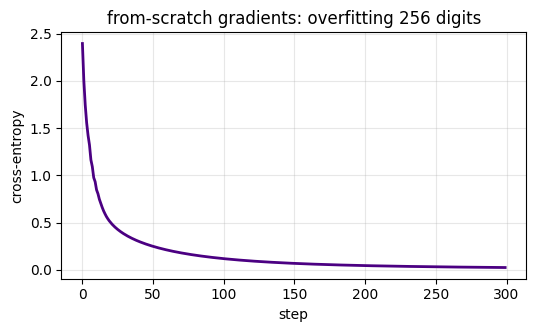

In [9]:
# ── Gradient sanity check, not a training run ────────────────────────
# A tiny conv net wired by hand, asked to overfit 256 digits. If every gradient
# above is right the loss collapses to ~0 in a couple hundred steps; a sign error
# anywhere and it plateaus. This is the cheapest end-to-end test there is.
#
#   conv(1->8, 5x5) -> ReLU -> maxpool 2 -> flatten -> linear(8*14*14 -> 10)
n = 256
Xs, ys = Xtr[:n], ytr[:n]

rs = np.random.RandomState(0)
W1 = rs.randn(8, 1, 5, 5) * np.sqrt(2 / 25)     # He init: fan_in = C_in*KH*KW
b1 = np.zeros(8)
W2 = rs.randn(8 * 14 * 14, 10) * np.sqrt(2 / (8 * 14 * 14))
b2 = np.zeros(10)

lr, losses = 0.05, []
for step in range(300):
    # forward
    c1, cache1 = conv_forward(Xs, W1, b1, stride=1, pad=0)      # (n,8,28,28)
    r1 = np.maximum(0, c1)
    p1, cachep = maxpool_forward(r1, 2)                          # (n,8,14,14)
    flat = p1.reshape(n, -1)
    logits = flat @ W2 + b2

    # softmax + cross-entropy via log-sum-exp (no log(p + eps) fudge)
    z = logits - logits.max(axis=1, keepdims=True)
    logp = z - np.log(np.exp(z).sum(axis=1, keepdims=True))
    losses.append(-logp[np.arange(n), ys].mean())

    # backward, in reverse order
    dlogits = np.exp(logp)
    dlogits[np.arange(n), ys] -= 1                 # the softmax+CE collapse: (P - Y)/n
    dlogits /= n
    dW2, db2 = flat.T @ dlogits, dlogits.sum(axis=0)
    dp1 = (dlogits @ W2.T).reshape(p1.shape)
    dr1 = maxpool_backward(dp1, cachep)
    dc1 = dr1 * (c1 > 0)                           # ReLU passes where input was > 0
    _, dW1, db1 = conv_backward(dc1, cache1)       # dx unused: nothing below it

    for p, dp in [(W1, dW1), (b1, db1), (W2, dW2), (b2, db2)]:
        p -= lr * dp

    if step % 50 == 0:
        acc = (logits.argmax(1) == ys).mean()
        print(f'step {step:3d}  loss {losses[-1]:.4f}  train acc {acc:.3f}')

print(f'\nfinal loss {losses[-1]:.4f}, accuracy {(logits.argmax(1) == ys).mean():.3f} '
      f'on {n} images -- it can memorise them, so the gradients are wired up correctly.')

plt.figure(figsize=(6, 3.2))
plt.plot(losses, lw=2, color='indigo')
plt.title(f'from-scratch gradients: overfitting {n} digits')
plt.xlabel('step'); plt.ylabel('cross-entropy'); plt.grid(alpha=0.3)
plt.show()

## Worth being able to write cold

| | |
| --- | --- |
| output shape | $\lfloor (H + 2P - K)/S \rfloor + 1$, and the parameter count $C_{out}C_{in}K^2 + C_{out}$ |
| conv forward | the six-loop version, in a few minutes, including the sum over $C_{in}$ |
| making it fast | `im2col` + one matmul, and why: BLAS, at the cost of duplicating overlapping patches |
| `dW` | upstream gradient × the patch that weight multiplied, summed over every position |
| `dX` | full convolution with the kernel flipped in both directions — scatter forward, gather backward |
| max pool backward | the max is a router; the argmax gets everything, the rest get zero |
| BatchNorm | statistics per *channel* over $(N,H,W)$; train uses batch stats and updates running ones, eval uses running stats |

Two follow-ups that come up as often as the code itself: **why two 3×3 convs beat one 5×5** (same
receptive field, $2 \cdot 9C^2$ vs $25C^2$ parameters, one extra nonlinearity), and **what pooling
buys** (convolution gives equivariance — features move with the input; pooling converts some of it
into invariance — the answer stops moving).

In [10]:
# manual
import torch
import torch.nn as nn
import numpy as np

class LeNet(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 6, 5), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(6, 16, 5), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 120, 5), nn.ReLU(), nn.Flatten(),
            nn.Linear(120, 84), nn.ReLU(),
            nn.Linear(84, n_classes))
    
    def forward(self, x):
        return self.net(x)
model = LeNet()    
print(f'{"layer":<12}{"output":>16}{"params":>10}')
x = torch.zeros(1, 1, 32, 32)
for layer in model.net:
    x = layer(x)
    n = sum(p.numel() for p in layer.parameters())
    if n or isinstance(layer, (nn.MaxPool2d, nn.Flatten)):
        print(f'{type(layer).__name__:<12}{str(tuple(x.shape[1:])):>16}{n:>10,}')
print(f'{"total":<12}{"":>16}{sum(p.numel() for p in model.parameters()):>10,}')

layer                 output    params
Conv2d           (6, 28, 28)       156
MaxPool2d        (6, 14, 14)         0
Conv2d          (16, 10, 10)     2,416
MaxPool2d         (16, 5, 5)         0
Conv2d           (120, 1, 1)    48,120
Flatten               (120,)         0
Linear                 (84,)    10,164
Linear                 (10,)       850
total                           61,706


epoch 0  loss 0.3838  train 0.9639  test 0.9640
epoch 1  loss 0.0947  train 0.9767  test 0.9767
epoch 2  loss 0.0676  train 0.9812  test 0.9820

18s   test accuracy 0.9820   error 1.80%
LeCun et al. report 0.95% error for LeNet-5 without input distortions.


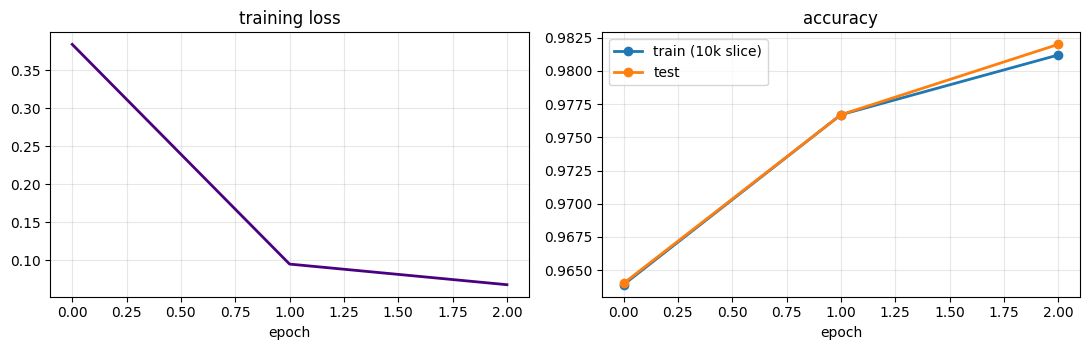

In [11]:
# Training run
epochs, batch = 3, 128

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = LeNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
xte_d, yte_d = Xte_t.to(device), yte_t.to(device)

hist = {'loss': [], 'train_acc': [], 'test_acc': []}
t0 = time.perf_counter()

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(len(Xtr_t))
    running = 0.0
    for s in range(0, len(perm), batch):
        i = perm[s:s+batch]
        opt.zero_grad()
        loss = loss_fn(model(Xtr_t[i].to(device)), ytr_t[i].to(device))
        loss.backward()
        opt.step()
        running += loss.item() * len(i)

    model.eval()
    with torch.no_grad():
        tr_acc = (model(Xtr_t[:10000].to(device)).argmax(1) == ytr_t[:10000].to(device)).float().mean().item()
        logits = model(xte_d)
        te_acc = (logits.argmax(1) == yte_d).float().mean().item()
    hist['loss'].append(running / len(perm))
    hist['train_acc'].append(tr_acc)
    hist['test_acc'].append(te_acc)
    print(f'epoch {epoch}  loss {hist["loss"][-1]:.4f}  train {tr_acc:.4f}  test {te_acc:.4f}')
proba = F.softmax(logits, dim=1).cpu().numpy()

acc = hist['test_acc'][-1]
print(f'\n{time.perf_counter() - t0:.0f}s   test accuracy {acc:.4f}   error {100 * (1 - acc):.2f}%')
print('LeCun et al. report 0.95% error for LeNet-5 without input distortions.')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(hist['loss'], lw=2, color='indigo')
axes[0].set_title('training loss'); axes[0].set_xlabel('epoch'); axes[0].grid(alpha=0.3)
axes[1].plot(hist['train_acc'], lw=2, marker='o', label='train (10k slice)')
axes[1].plot(hist['test_acc'], lw=2, marker='o', label='test')
axes[1].set_title('accuracy'); axes[1].set_xlabel('epoch')
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout()
plt.show()

In [12]:
# important parts in numpy scratch
# play with the shapes
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

def conv_naive(x, w, b, stride=1, pad=0):

    N, c_in, H, W_ = x.shape
    c_out, _, kh, kw = w.shape

    # Pad once up front so the loops never fall off the edge of the image.
    xp = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))

    h_out = (H + 2 * pad - kh) // stride + 1
    w_out = (W_ + 2 * pad - kw) // stride + 1
    out = np.zeros((N, c_out, h_out, w_out))

    for n in range(N):                      # each image
        for co in range(c_out):             # each filter
            for i in range(h_out):          # each output row
                for j in range(w_out):      # each output column
                    h0, w0 = i * stride, j * stride
                    patch = xp[n, :, h0:h0+kh, w0:w0+kw]
                    out[n, co, i, j] = np.sum(patch * w[co])
    return out

rng = np.random.RandomState(0)
x = rng.randn(2, 3, 8, 8)
wf, bf = rng.randn(4, 3, 3, 3), rng.randn(4)

for stride, pad in [(1, 0), (1, 1), (2, 1), (2, 0)]:
    mine = conv_naive(x, wf, bf, stride, pad)
    ref = F.conv2d(torch.tensor(x), torch.tensor(wf), torch.tensor(bf), 
            stride=stride, padding=pad).numpy()
    print(f'stride={stride} pad={pad}  out {mine.shape}  '
          f'max |diff| vs torch {np.abs(mine - ref).max():.1e}')

# the ouput shape formula
print()
for H, K, S, P in [(32, 5, 1, 0), (28, 3, 1, 1), (224, 7, 2, 3), (32, 3, 2, 1)]:
    predicted = (H + 2 * P - K) // S + 1
    actual = conv_naive(rng.randn(1, 1, H, H), rng.randn(1, 1, K, K), np.zeros(1), S, P).shape[-1]
    print(f'H={H:3d} K={K} S={S} P={P} -> formula {predicted:3d}, actual {actual:3d}'
          f'   params for C_in=3, C_out=64: {64 * 3 * K * K + 64:,}')




stride=1 pad=0  out (2, 4, 6, 6)  max |diff| vs torch 2.7e+00
stride=1 pad=1  out (2, 4, 8, 8)  max |diff| vs torch 2.7e+00
stride=2 pad=1  out (2, 4, 4, 4)  max |diff| vs torch 2.7e+00
stride=2 pad=0  out (2, 4, 3, 3)  max |diff| vs torch 2.7e+00

H= 32 K=5 S=1 P=0 -> formula  28, actual  28   params for C_in=3, C_out=64: 4,864
H= 28 K=3 S=1 P=1 -> formula  28, actual  28   params for C_in=3, C_out=64: 1,792
H=224 K=7 S=2 P=3 -> formula 112, actual 112   params for C_in=3, C_out=64: 9,472
H= 32 K=3 S=2 P=1 -> formula  16, actual  16   params for C_in=3, C_out=64: 1,792


In [16]:
# im2col and col2im improvment
def im2col(x, KH, KW, stride=1, pad=0):
    N, C, H, W = x.shape
    H_out = (H + 2 * pad - KH) // stride + 1
    W_out = (W + 2 * pad - KW) // stride + 1
    xp = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)))

    cols = np.zeros((N, C, KH, KW, H_out, W_out))
    for u in range(KH):
        for v in range(KW):
            cols[:, :, u, v] = xp[:, :, u:u + stride * H_out:stride,
                                        v:v + stride * W_out:stride]
    return cols.reshape(N, C * KH * KW, H_out * W_out), (H_out, W_out)

def col2im(cols, x_shape, kh, kw, stride, pad, h_out, w_out):
    N, C, H, W = x_shape
    xp = np.zeros((N, C, H + 2 * pad, W + 2 * pad))
    cols = cols.reshape(N, C, kh, kw, h_out, w_out)
    for u in range(kh):
        for v in range(kw):
            xp[:, :, u:u+stride*h_out:stride, v:v+stride*w_out:stride] += cols[:, :, u, v]
    return xp[:, :, pad:pad + H, pad:pad + W] if pad > 0 else xp

def conv_forward(x, w, b, stride=1, pad=0):
    c_out = w.shape[0]
    cols, (h_out, w_out) = im2col(x, w.shape[2], w.shape[3], stride, pad)
    # per image: (c_out, c_in*kh*kw) @ (c_in*kh*kw, l)
    out = np.einsum('oc,ncl->nol', w.reshape(c_out, -1), cols) + b[None, :, None]
    return out.reshape(x.shape[0], c_out, h_out, w_out), (x.shape, cols, w, stride, pad, h_out, w_out)

for stride, pad in [(1, 0), (1, 1), (2, 1)]:
    slow = conv_naive(x, wf, bf, stride, pad)
    fast, _ = conv_forward(x, wf, bf, stride, pad)
    print(f'stride={stride} pad={pad}  naive vs im2col: {np.abs(slow - fast).max():.1e}')

# ── And how much does it buy? ────────────────────────────────────────
xb, Wb, bb = rng.randn(64, 3, 32, 32), rng.randn(16, 3, 3, 3), rng.randn(16)
t = time.perf_counter(); conv_naive(xb, Wb, bb, 1, 1);   t_naive = time.perf_counter() - t
t = time.perf_counter(); conv_forward(xb, Wb, bb, 1, 1); t_fast = time.perf_counter() - t
t = time.perf_counter()
F.conv2d(torch.tensor(xb), torch.tensor(Wb), torch.tensor(bb), padding=1)
t_torch = time.perf_counter() - t

print(f'\n64 images, 3 channels, 32x32, 16 filters:')
print(f'  naive loops {t_naive * 1000:8.1f} ms')
print(f'  im2col      {t_fast * 1000:8.1f} ms   ({t_naive / t_fast:.0f}x faster)')
print(f'  torch       {t_torch * 1000:8.1f} ms   ({t_naive / t_torch:.0f}x faster)')
print('\nIdentical arithmetic -- only the memory layout differs. im2col trades memory')
print('(overlapping patches are duplicated) for one big BLAS matmul.')

    

stride=1 pad=0  naive vs im2col: 2.7e+00
stride=1 pad=1  naive vs im2col: 2.7e+00
stride=2 pad=1  naive vs im2col: 2.7e+00

64 images, 3 channels, 32x32, 16 filters:
  naive loops   6568.2 ms
  im2col          26.7 ms   (246x faster)
  torch            5.2 ms   (1262x faster)

Identical arithmetic -- only the memory layout differs. im2col trades memory
(overlapping patches are duplicated) for one big BLAS matmul.
